<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/LongTermInvesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install --upgrade yfinance


In [13]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
from datetime import datetime
import time
import seaborn as sns
import matplotlib.pyplot as plt
print("Libraries Installed!")

0.2.66
Libraries Installed!


In [8]:

def get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66, period="3mo", interval="1d"):
    """
    Filters a ranked list of tickers to return only uncorrelated picks.

    Parameters:
    -----------
    tickers : list
        All candidate tickers.
    ranked_picks : list
        Ranked list of tickers (best to worst).
    threshold : float
        Correlation threshold (default 0.66).
    period : str
        Data period for yfinance (default "3mo").
    interval : str
        Data interval (default "1d").

    Returns:
    --------
    final_selection : list
        List of uncorrelated tickers.
    corr_matrix : DataFrame
        Correlation matrix of daily returns.
    """
    # Step 1: Get prices
    data = yf.download(tickers, period=period, interval=interval,auto_adjust=True)["Close"]
    data = data.ffill()

    # Step 2: Convert to daily returns
    returns = data.pct_change().dropna()

    # Step 3: Correlation matrix
    corr_matrix = returns.corr()

    # Step 4: Filter uncorrelated picks
    final_selection = []
    for pick in ranked_picks:
        if all(abs(corr_matrix.loc[pick, sel]) <= threshold for sel in final_selection):
            final_selection.append(pick)

    return final_selection, corr_matrix




[*********************100%***********************]  34 of 34 completed


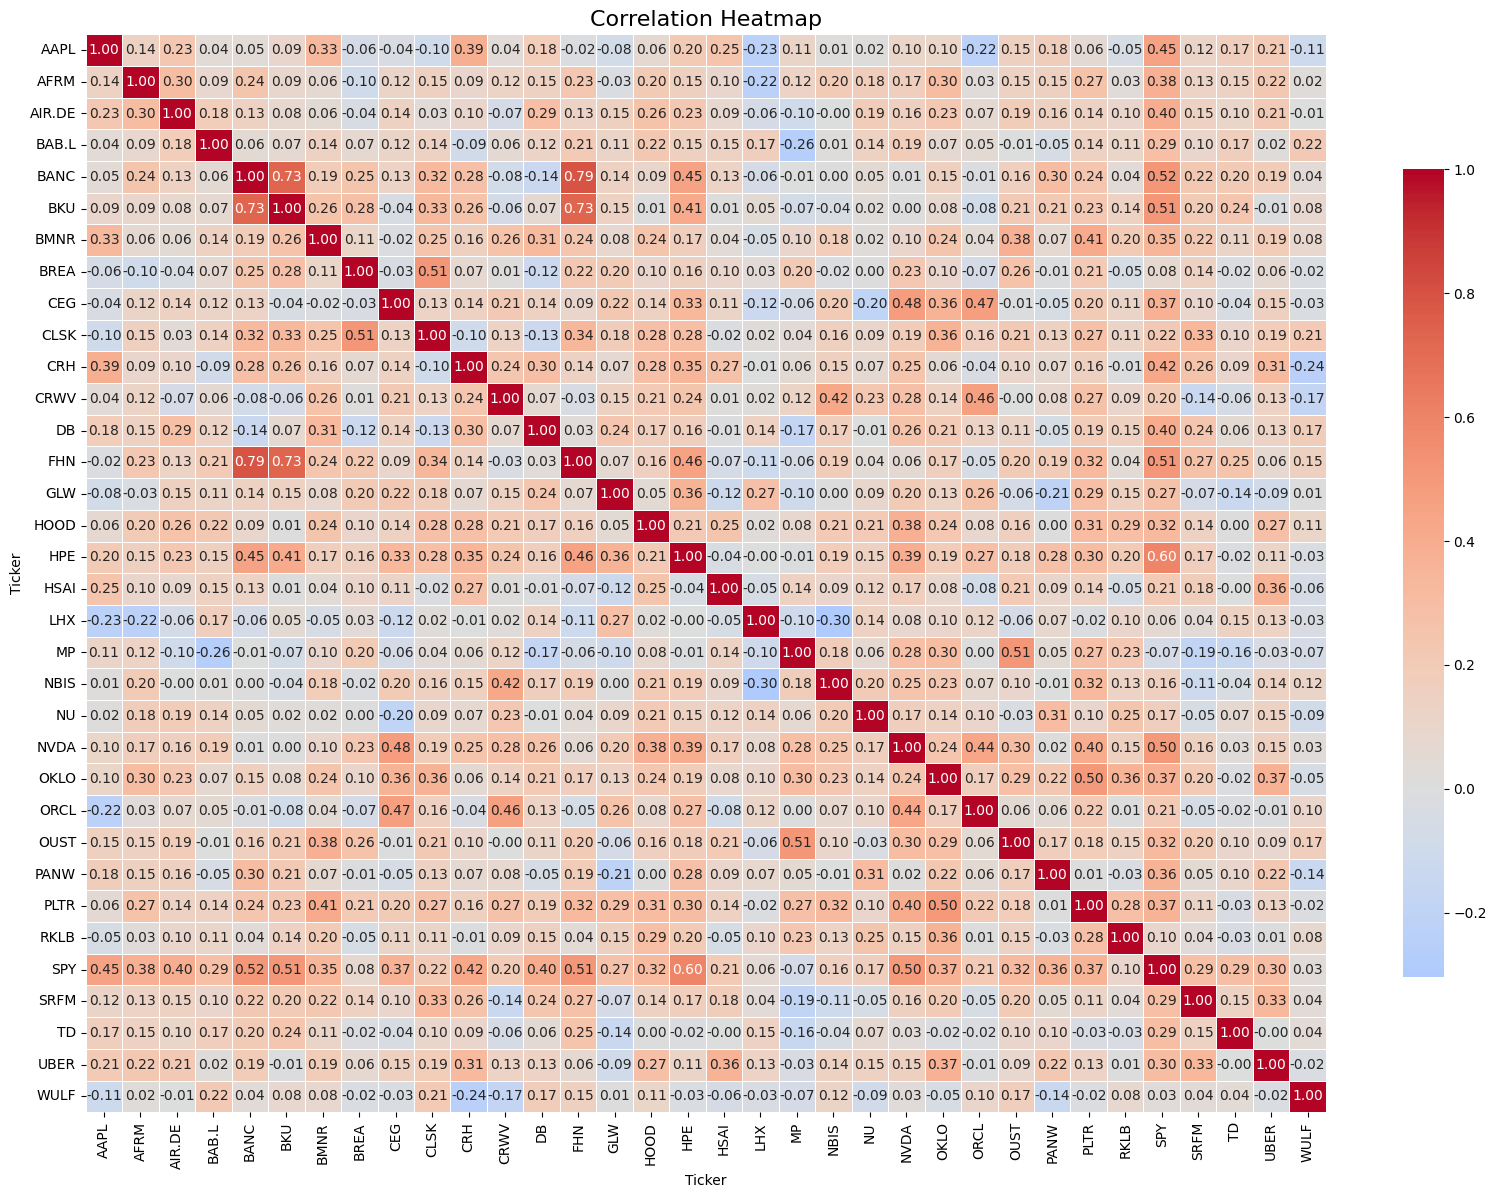

In [15]:
df_raw = pd.read_csv('longterm.csv')

# Example usage
tickers = df_raw['Asset'].to_list()
ranked_picks = tickers


final_selection, corr_matrix = get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66)

# Step 2: Set up the matplotlib figure
plt.figure(figsize=(20, 14))

# Step 3: Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,         # Show correlation values
    fmt=".2f",          # Format to 2 decimal places
    cmap="coolwarm",    # Color map
    center=0,           # Center the colormap at 0
    linewidths=0.5,     # Lines between cells
    cbar_kws={"shrink": 0.75}  # Shrink color bar
)

# Step 4: Add title and show
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [21]:

#print("Final uncorrelated picks:", final_selection)
#print("\nCorrelation matrix:\n", corr_matrix)

# Keep only rows where Asset is in filtered
filtered_list = df_raw[df_raw["Asset"].isin(final_selection)]

buy_list = filtered_list.copy()
buy_list.head()

,Asset,Momentum,score
0,WULF,Strong,4.60
1,NBIS,Strong,4.08
2,OKLO,Strong,2.27
3,CLSK,Strong,2.17
4,BMNR,Strong,1.99


In [24]:
def money_flow_signals(df, period=10):
    """
    Calculate Money Flow Index (MFI) and generate signals:
    - Positive money flow (TP > TP_prev)
    - Divergence (Price vs MFI mismatch)

    Parameters:
        df (pd.DataFrame): DataFrame with columns ["High", "Low", "Close", "Volume"]
        period (int): Lookback period for MFI (default=10)

    Returns:
        pd.DataFrame with added columns: ["TypicalPrice", "MFI", "PositiveFlow", "Divergence"]
    """

    df = df.copy()

    # Step 1: Typical Price
    df["TypicalPrice"] = (df["High"] + df["Low"] + df["Close"]) / 3

    # Step 2: Raw Money Flow
    df["RawMoneyFlow"] = df["TypicalPrice"] * df["Volume"]

    # Step 3: Positive & Negative Flow
    df["PositiveFlow"] = np.where(df["TypicalPrice"] > df["TypicalPrice"].shift(1), df["RawMoneyFlow"], 0.0)
    df["NegativeFlow"] = np.where(df["TypicalPrice"] < df["TypicalPrice"].shift(1), df["RawMoneyFlow"], 0.0)

    # Step 4: Money Flow Ratio & MFI
    pos_flow = df["PositiveFlow"].rolling(period).sum()
    neg_flow = df["NegativeFlow"].rolling(period).sum()
    money_flow_ratio = pos_flow / neg_flow.replace(0, np.nan)
    df["MFI"] = 100 - (100 / (1 + money_flow_ratio))

    # Step 5: Positive Money Flow Signal
    df["PositiveFlowSignal"] = df["TypicalPrice"] > df["TypicalPrice"].shift(1)

    # Step 6: Divergence Detection
    df["PriceHigh"] = df["Close"].rolling(period).max()
    df["PriceLow"] = df["Close"].rolling(period).min()
    df["MFIHigh"] = df["MFI"].rolling(period).max()
    df["MFILow"] = df["MFI"].rolling(period).min()

    def divergence(row):
        if np.isnan(row["MFI"]):
            return None
        # Price makes higher high, but MFI does not
        if row["Close"] >= row["PriceHigh"] and row["MFI"] < row["MFIHigh"]:
            return "Bearish Divergence ⚠️"
        # Price makes lower low, but MFI does not
        elif row["Close"] <= row["PriceLow"] and row["MFI"] > row["MFILow"]:
            return "Bullish Divergence ✅"
        else:
            return "No Divergence"

    df["Divergence"] = df.apply(divergence, axis=1)
    df['Entry_signal']= (df["MFI"] > 50) & (df["Divergence"] == "No Divergence")
    curr = df.iloc[-1]

    return curr.Entry_signal

In [22]:
def check_entry_conditions(tickers):
    results = []
    for ticker in tickers:
      df = yf.download(ticker, period="1y", interval="1d",auto_adjust=True)
      if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)  # keep only first leve
      mfi_signal = money_flow_signals(df)
      # Print results
      print(f"Money flow indicator for {ticker} is:")
      print(mfi_signal)

      refined_entry_signal = mfi_signal


      if mfi_signal :
        entry_signal = "Entry"
      else:
        entry_signal = "Bearish"
      results.append([ticker, entry_signal])
    # Convert results to DataFrame
    df_results = pd.DataFrame(results, columns=["Asset", "Entry_Signal"])
    return df_results


In [27]:
final_etfs_to_check = buy_list['Asset'].to_list()
buy_lists = check_entry_conditions(final_etfs_to_check)
buy_lists[buy_lists['Entry_Signal'] =="Entry"]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Money flow indicator for WULF is:
True
Money flow indicator for NBIS is:
False


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Money flow indicator for OKLO is:
True
Money flow indicator for CLSK is:
True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


...

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Money flow indicator for TD is:
False
Money flow indicator for LHX is:
True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Money flow indicator for DB is:
False
Money flow indicator for SPY is:
True


,Asset,Entry_Signal
0,WULF,Entry
2,OKLO,Entry
3,CLSK,Entry
4,BMNR,Entry
6,RKLB,Entry
7,GLW,Entry
8,OUST,Entry
11,SRFM,Entry
12,HPE,Entry
14,CRH,Entry
